In [ ]:
import pandas as pd
df = pd.read_csv('mtsamples.csv',engine="python",encoding="utf-8",on_bad_lines="skip")

In [ ]:
df = df.drop('Unnamed: 0',axis=1)

In [ ]:
df.head()

,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
df.isnull().sum()

,0
description,0
medical_specialty,0
sample_name,0
transcription,33
keywords,1068


In [ ]:
df.shape

(4999, 5)

In [ ]:
# Since sample_name is the title of the report so it is pretty useless
df = df.drop('sample_name',axis=1)

In [ ]:
# Since transcription is the main input so where transaction is NaN drop that rows
df = df[~(df['transcription'].isnull())]

In [ ]:
df.head()

,description,medical_specialty,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,2-D Echocardiogram,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


<Axes: >

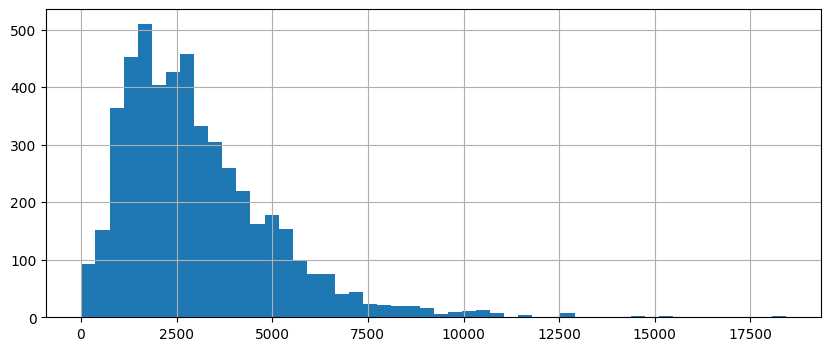

In [ ]:
import matplotlib.pyplot as plt
df['transcription'].astype(str).apply(len).hist(bins=50, figsize=(10,4))

In [ ]:
df['transcription'].astype(str).apply(len).describe()

,transcription
count,4966.000000
mean,3052.314337
std,1994.082239
min,11.000000
25%,1608.000000
50%,2667.000000
75%,4011.000000
max,18425.000000


In [ ]:
df[df['transcription'].astype(str).apply(len)>10000]

,description,medical_specialty,transcription,keywords
149,"Exploratory laparotomy, resection of small bo...",Urology,"PREOPERATIVE DIAGNOSES:,1. Clinical stage T2,...",
407,The patient is a 9-year-old born with pulmona...,Surgery,"HISTORY: , The patient is a 9-year-old born wi...",NaN
917,Delayed open reduction internal fixation with...,Surgery,"PREOPERATIVE DIAGNOSES:,1. Right ankle trimal...",NaN
943,"Exploratory laparotomy, resection of small bo...",Surgery,"PREOPERATIVE DIAGNOSES:,1. Clinical stage T2,...",
977,A 10-1/2-year-old born with asplenia syndrome...,Surgery,"HISTORY:, The patient is a 10-1/2-year-old bo...",NaN
1118,"Bunionectomy, right foot with Biopro hemi imp...",Surgery,"PREOPERATIVE DIAGNOSES:,1. Hallux abductovalg...",NaN
1205,"Arthrotomy, removal humeral head implant, rig...",Surgery,"TITLE OF OPERATION: ,1. Arthrotomy, removal ...","surgery, arthrotomy, repair of torn subscapula..."
1774,Psychiatric Assessment of a patient with bipo...,Psychiatry / Psychology,"IDENTIFICATION OF PATIENT: , This is a 31-year...",NaN
1788,Psychiatric Consultation of patient with recu...,Psychiatry / Psychology,"CC: , ""Five years ago, I stopped drinking and ...",NaN
1792,The patient is a 58-year-old African-American...,Psychiatry / Psychology,"REASON FOR REFERRAL:, The patient is a 58-yea...",NaN


In [ ]:
# Dropped whose length is more than 10000
df = df[~(df['transcription'].astype(str).apply(len)>10000)]

<Axes: >

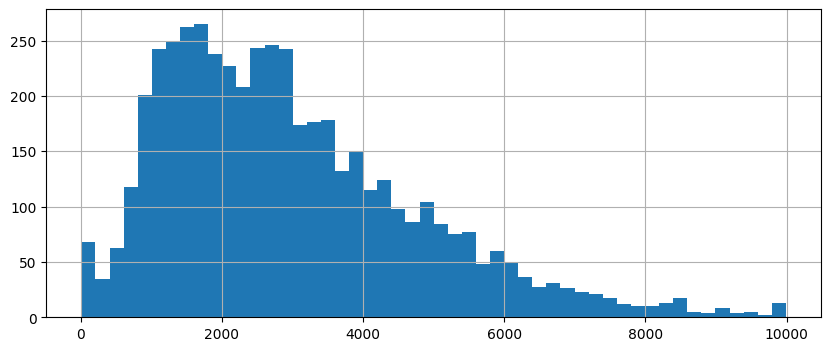

In [ ]:
df['transcription'].astype(str).apply(len).hist(bins=50, figsize=(10,4))

In [ ]:
df['text_length'] = df['transcription'].astype(str).apply(len)

In [ ]:
df.head()

,description,medical_specialty,transcription,keywords,text_length
0,A 23-year-old white female presents with comp...,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",1331
1,Consult for laparoscopic gastric bypass.,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431
2,Consult for laparoscopic gastric bypass.,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",4422
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",495
4,2-D Echocardiogram,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",1618


In [ ]:
import pandas as pd
import torch
from transformers import BartForConditionalGeneration, AutoTokenizer

model_name = "sshleifer/distilbart-cnn-12-6"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

print("Model loaded on:", "GPU" if torch.cuda.is_available() else "CPU")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded on: GPU


In [ ]:
def chunk_text(text, max_tokens=900, overlap=50):
    tokens = tokenizer.encode(text, truncation=False)
    chunks = []
    start = 0
    while start < len(tokens):
        end = min(start + max_tokens, len(tokens))
        chunk = tokenizer.decode(tokens[start:end], skip_special_tokens=True)
        chunks.append(chunk)
        start += max_tokens - overlap
    return chunks

def summarize_text(text, min_len=60, max_len=180):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=1024,
        truncation=True
    ).to(model.device)

    summary_ids = model.generate(
        inputs["input_ids"],
        max_length=max_len,
        min_length=min_len,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

def summarize_long_text(text, min_len=60, max_len=180):
    tokens = tokenizer.encode(text, truncation=False)

    if len(tokens) <= 1024:
        return summarize_text(text, min_len, max_len)

    # Chunk → summarize each → final pass
    chunks = chunk_text(text)
    chunk_summaries = [summarize_text(chunk, 40, 120) for chunk in chunks]
    combined = " ".join(chunk_summaries)
    return summarize_text(combined, min_len, max_len)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
import os
from tqdm import tqdm

checkpoint_file = 'mtsamples_checkpoint.csv'
BATCH_SIZE = 8

# Combine description + transcription
df['combined_text'] = (
    df['description'].fillna('') + ' ' + df['transcription'].fillna('')
).str.strip()

# Resume from checkpoint if exists
if os.path.exists(checkpoint_file):
    df_done = pd.read_csv(checkpoint_file)
    start_idx = df_done['patient_summary'].notna().sum()
    df['patient_summary'] = df_done['patient_summary']
    print(f"Resuming from row {start_idx}")
else:
    df['patient_summary'] = None
    start_idx = 0

for i in tqdm(range(start_idx, len(df))):
    df.at[i, 'patient_summary'] = summarize_long_text(df.at[i, 'combined_text'])
    if i % 100 == 0:
        df.to_csv(checkpoint_file, index=False)

df.to_csv('mtsamples_with_summary.csv', index=False)

Resuming from row 333


100%|██████████| 4588/4588 [1:50:47<00:00,  1.45s/it]


In [ ]:
df.head()

,description,medical_specialty,transcription,keywords,text_length,combined_text,patient_summary
0,A 23-year-old white female presents with comp...,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",1331,A 23-year-old white female presents with compl...,A 23-year-old white female presents with comp...
1,Consult for laparoscopic gastric bypass.,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431,Consult for laparoscopic gastric bypass. PAST ...,Consult for laparoscopic gastric bypass . Has...
2,Consult for laparoscopic gastric bypass.,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",4422,Consult for laparoscopic gastric bypass. HISTO...,He has been overweight for ten years since th...
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",495,"2-D M-Mode. Doppler. 2-D M-MODE: , ,1. Left...",Left atrial enlargement with left atrial diam...
4,2-D Echocardiogram,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",1618,2-D Echocardiogram 1. The left ventricular ca...,The study was somewhat technically limited an...


In [ ]:
from rouge_score import rouge_scorer
import pandas as pd
import numpy as np

df = pd.read_csv('mtsamples_with_summary.csv')
df = df.dropna(subset=['patient_summary', 'description'])

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

for _, row in df.iterrows():
    score = scorer.score(
        str(row['description']),      # reference
        str(row['patient_summary'])   # generated
    )
    scores['rouge1'].append(score['rouge1'].fmeasure)
    scores['rouge2'].append(score['rouge2'].fmeasure)
    scores['rougeL'].append(score['rougeL'].fmeasure)

print("=== ROUGE Scores ===")
print(f"ROUGE-1 : {np.mean(scores['rouge1']):.4f}")
print(f"ROUGE-2 : {np.mean(scores['rouge2']):.4f}")
print(f"ROUGE-L : {np.mean(scores['rougeL']):.4f}")

=== ROUGE Scores ===
ROUGE-1 : 0.3548
ROUGE-2 : 0.2935
ROUGE-L : 0.3321


In [ ]:
import pandas as pd
df = pd.read_csv('mtsamples_with_summary.csv')

In [ ]:
df.head()

,description,medical_specialty,transcription,keywords,text_length,combined_text,patient_summary
0,A 23-year-old white female presents with comp...,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",1331,A 23-year-old white female presents with compl...,A 23-year-old white female presents with comp...
1,Consult for laparoscopic gastric bypass.,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431,Consult for laparoscopic gastric bypass. PAST ...,Consult for laparoscopic gastric bypass . Has...
2,Consult for laparoscopic gastric bypass.,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",4422,Consult for laparoscopic gastric bypass. HISTO...,He has been overweight for ten years since th...
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",495,"2-D M-Mode. Doppler. 2-D M-MODE: , ,1. Left...",Left atrial enlargement with left atrial diam...
4,2-D Echocardiogram,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",1618,2-D Echocardiogram 1. The left ventricular ca...,The study was somewhat technically limited an...


In [ ]:
!pip install keybert sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 625.1 kB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_csv('mtsamples_with_summary.csv')
df = df.dropna(subset=['patient_summary'])
print(f"Rows available: {df.shape[0]}")
df[['patient_summary', 'keywords']].head(3)

Rows available: 4921


,patient_summary,keywords
0,A 23-year-old white female presents with comp...,"allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass . Has...,"bariatrics, laparoscopic gastric bypass, weigh..."
2,He has been overweight for ten years since th...,"bariatrics, laparoscopic gastric bypass, heart..."


In [ ]:
from keybert import KeyBERT
from sentence_transformers import SentenceTransformer

# Medical domain BioBERT embedding model
embedding_model = SentenceTransformer("pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb")
kw_model = KeyBERT(model=embedding_model)

print("KeyBERT model loaded ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.47k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/669k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

KeyBERT model loaded ✅


In [ ]:
def extract_keywords(text, top_n=10):
    if not text or len(str(text).strip()) == 0:
        return ""

    keywords = kw_model.extract_keywords(
        str(text),
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=top_n,
        use_mmr=True,       # Maximal Marginal Relevance for diversity
        diversity=0.5       # avoid redundant keywords
    )

    return ", ".join([kw[0] for kw in keywords])

In [ ]:
from tqdm import tqdm
import os

checkpoint_file = 'mtsamples_with_keywords.csv'

# Resume from checkpoint if exists
if os.path.exists(checkpoint_file):
    df_done = pd.read_csv(checkpoint_file)
    df['extracted_keywords'] = df_done['extracted_keywords']
    start_idx = df['extracted_keywords'].notna().sum()
    print(f"Resuming from row {start_idx}")
else:
    df['extracted_keywords'] = None
    start_idx = 0

for i in tqdm(range(start_idx, len(df))):
    df.at[i, 'extracted_keywords'] = extract_keywords(df.at[i, 'patient_summary'])

    if i % 100 == 0:
        df.to_csv(checkpoint_file, index=False)

df.to_csv('mtsamples_with_keywords.csv', index=False)
print("All done ✅")


100%|██████████| 4921/4921 [06:58<00:00, 11.77it/s]


All done ✅


In [11]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

eval_model = SentenceTransformer("all-MiniLM-L6-v2")

eval_df = df.dropna(subset=['extracted_keywords', 'keywords'])

def keyword_similarity(kw1, kw2):
    if not kw1 or not kw2:
        return 0.0
    emb1 = eval_model.encode([str(kw1)])
    emb2 = eval_model.encode([str(kw2)])
    return cosine_similarity(emb1, emb2)[0][0]

scores = []
for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    score = keyword_similarity(row['extracted_keywords'], row['keywords'])
    scores.append(score)

print("=== Keyword Extraction Evaluation ===")
print(f"Mean Cosine Similarity : {np.mean(scores):.4f}")
print(f"Median                 : {np.median(scores):.4f}")
print(f"Min                    : {np.min(scores):.4f}")
print(f"Max                    : {np.max(scores):.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 3887/3887 [01:14<00:00, 52.02it/s]

=== Keyword Extraction Evaluation ===
Mean Cosine Similarity : 0.6199
Median                 : 0.6399
Min                    : -0.0317
Max                    : 0.9166


In [12]:
df.to_csv('mtsamples_with_keywords.csv', index=False)
df.head(3)

,description,medical_specialty,transcription,keywords,text_length,combined_text,patient_summary,extracted_keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",1331,A 23-year-old white female presents with compl...,A 23-year-old white female presents with comp...,"allergies lived, cyclen allegra, medication cu..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431,Consult for laparoscopic gastric bypass. PAST ...,Consult for laparoscopic gastric bypass . Has...,"stairs difficulty, gastroesophageal reflux, hy..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",4422,Consult for laparoscopic gastric bypass. HISTO...,He has been overweight for ten years since th...,"overweight, bypass risks, gastrojejuno anastom..."


In [13]:
!pip install negspacy spacy -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv('mtsamples_with_keywords.csv')

high_risk_terms = [
    'cancer', 'tumor', 'malignant', 'hemorrhage', 'sepsis',
    'failure', 'acute', 'critical', 'carcinoma', 'metastasis',
    'stroke', 'infarction', 'embolism', 'thrombosis', 'necrosis',
    'rupture', 'obstruction', 'seizure', 'unconscious', 'fatal',
    'emergency', 'severe', 'massive', 'invasive', 'aggressive'
]

medium_risk_terms = [
    'infection', 'inflammation', 'chronic', 'hypertension',
    'diabetes', 'fracture', 'disorder', 'syndrome', 'abnormal',
    'deficiency', 'dysfunction', 'pain', 'injury', 'disease',
    'lesion', 'mass', 'elevated', 'reduced', 'impaired',
    'moderate', 'persistent', 'recurrent', 'progressive'
]

def term_score(row):
    text = (
        str(row['extracted_keywords']).lower() + ' ' +
        str(row['patient_summary']).lower()
    )
    high = sum(1 for t in high_risk_terms if t in text)
    medium = sum(1 for t in medium_risk_terms if t in text)
    return high, medium

df[['high_term_score', 'medium_term_score']] = df.apply(
    lambda row: pd.Series(term_score(row)), axis=1
)
print("Signal 1 done ✅")

Signal 1 done ✅


In [15]:
specialty_risk_map = {
    # High risk specialties
    'Cardiovascular / Pulmonary'    : 3,
    'Neurology'                     : 3,
    'Oncology'                      : 3,
    'Emergency Room Reports'        : 3,
    'Intensive Care Unit (ICU)'     : 3,
    'Nephrology'                    : 3,
    'Hematology - Oncology'         : 3,
    'Neurosurgery'                  : 3,

    # Medium risk specialties
    'Gastroenterology'              : 2,
    'Orthopedic'                    : 2,
    'Endocrinology'                 : 2,
    'Urology'                       : 2,
    'Obstetrics / Gynecology'       : 2,
    'Psychiatry / Psychology'       : 2,
    'Pulmonology'                   : 2,
    'Rheumatology'                  : 2,
    'Infectious Disease'            : 2,

    # Low risk specialties
    'Dentistry'                     : 1,
    'Dermatology'                   : 1,
    'Ophthalmology'                 : 1,
    'Physical Medicine - Rehab'     : 1,
    'Podiatry'                      : 1,
    'Allergy / Immunology'          : 1,
    'Cosmetic / Plastic Surgery'    : 1,
}

df['specialty_score'] = df['medical_specialty'].str.strip().map(
    specialty_risk_map
).fillna(2)  # unknown specialties default to medium

print("Signal 2 done ✅")
print(df['specialty_score'].value_counts())

Signal 2 done ✅
specialty_score
2.0    3753
3.0     928
1.0     240
Name: count, dtype: int64


In [16]:
def complexity_score(text):
    text = str(text)
    length = len(text)
    # Normalize to 1-3 scale
    if length > 5000:
        return 3
    elif length > 2000:
        return 2
    else:
        return 1

df['complexity_score'] = df['transcription'].apply(complexity_score)
print("Signal 3 done ✅")

Signal 3 done ✅


In [17]:
import spacy

nlp = spacy.load("en_core_web_sm")

def negation_penalty(text):
    """
    Detects negated risk terms and reduces score.
    e.g. 'no cancer' should NOT be high risk
    """
    text = str(text)[:500]  # limit for speed
    doc = nlp(text)

    negated_terms = 0
    for token in doc:
        if token.dep_ == 'neg':
            # Check if any high risk term is in same sentence
            sent_text = token.sent.text.lower()
            if any(t in sent_text for t in high_risk_terms):
                negated_terms += 1
    return negated_terms

df['negation_count'] = df['patient_summary'].fillna('').apply(negation_penalty)
print("Signal 4 done ✅")

Signal 4 done ✅


In [18]:
def compute_final_risk(row):
    # Weighted risk score
    score = (
        row['high_term_score']   * 3 +   # strongest signal
        row['medium_term_score'] * 1 +   # moderate signal
        row['specialty_score']   * 2 +   # domain knowledge
        row['complexity_score']  * 1 -   # case complexity
        row['negation_count']    * 2     # negation reduces risk
    )

    if score >= 12:
        return 'High'
    elif score >= 7:
        return 'Medium'
    else:
        return 'Low'

df['risk_label'] = df.apply(compute_final_risk, axis=1)

print("=== Risk Label Distribution ===")
print(df['risk_label'].value_counts())
print(f"\nPercentage:")
print((df['risk_label'].value_counts(normalize=True) * 100).round(1))

=== Risk Label Distribution ===
risk_label
Medium    2641
Low       1767
High       513
Name: count, dtype: int64

Percentage:
risk_label
Medium    53.7
Low       35.9
High      10.4
Name: proportion, dtype: float64


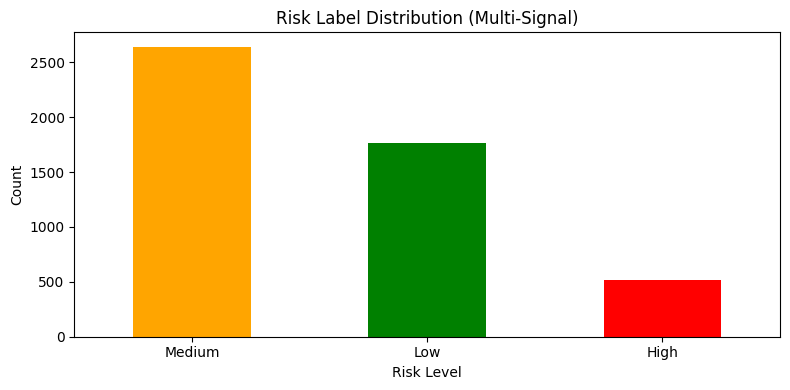

In [19]:
import matplotlib.pyplot as plt

colors = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}
counts = df['risk_label'].value_counts()

plt.figure(figsize=(8, 4))
counts.plot(
    kind='bar',
    color=[colors[c] for c in counts.index]
)
plt.title('Risk Label Distribution (Multi-Signal)')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
df.to_csv('mtsamples_with_risk.csv', index=False)
print("Saved ✅")
df.head(5)

Saved ✅


,description,medical_specialty,transcription,keywords,text_length,combined_text,patient_summary,extracted_keywords,high_term_score,medium_term_score,specialty_score,complexity_score,negation_count,risk_label
0,A 23-year-old white female presents with comp...,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller...",1331,A 23-year-old white female presents with compl...,A 23-year-old white female presents with comp...,"allergies lived, cyclen allegra, medication cu...",0,0,1.0,1,0,Low
1,Consult for laparoscopic gastric bypass.,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431,Consult for laparoscopic gastric bypass. PAST ...,Consult for laparoscopic gastric bypass . Has...,"stairs difficulty, gastroesophageal reflux, hy...",1,3,2.0,2,0,High
2,Consult for laparoscopic gastric bypass.,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart...",4422,Consult for laparoscopic gastric bypass. HISTO...,He has been overweight for ten years since th...,"overweight, bypass risks, gastrojejuno anastom...",3,1,2.0,2,0,High
3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",495,"2-D M-Mode. Doppler. 2-D M-MODE: , ,1. Left...",Left atrial enlargement with left atrial diam...,"left atrial, atrial enlargement, ventricular e...",0,0,3.0,1,0,Medium
4,2-D Echocardiogram,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",1618,2-D Echocardiogram 1. The left ventricular ca...,The study was somewhat technically limited an...,"left ventricular, subtle abnormalities, dopple...",0,2,3.0,1,0,Medium


In [21]:
!pip install xgboost sentence-transformers shap imbalanced-learn -q

In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv('mtsamples_with_risk.csv')
df = df.dropna(subset=['extracted_keywords', 'medical_specialty', 'risk_label'])

print(f"Dataset size: {df.shape}")
print(df['risk_label'].value_counts())


Dataset size: (4921, 14)
risk_label
Medium    2641
Low       1767
High       513
Name: count, dtype: int64


In [23]:
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Encode keywords semantically
encoder = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding keywords...")
keyword_embeddings = encoder.encode(
    df['extracted_keywords'].fillna('').tolist(),
    batch_size=64,
    show_progress_bar=True
)

# One-hot encode medical specialty
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
specialty_ohe = ohe.fit_transform(
    df[['medical_specialty']].fillna('Unknown')
)

# Concatenate all features
X = np.hstack([keyword_embeddings, specialty_ohe])

# Encode risk label
risk_encoder = LabelEncoder()
y = risk_encoder.fit_transform(df['risk_label'])

print(f"Feature shape : {X.shape}")
print(f"Classes       : {risk_encoder.classes_}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding keywords...


Batches:   0%|          | 0/77 [00:00<?, ?it/s]

Feature shape : (4921, 424)
Classes       : ['High' 'Low' 'Medium']


In [24]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Before SMOTE: {Counter(y)}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"After SMOTE : {Counter(y_resampled)}")

Before SMOTE: Counter({np.int64(2): 2641, np.int64(1): 1767, np.int64(0): 513})
After SMOTE : Counter({np.int64(1): 2641, np.int64(0): 2641, np.int64(2): 2641})


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")

Train size : 6338
Test size  : 1585


In [26]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nTraining complete ✅")

[0]	validation_0-mlogloss:1.05535
[50]	validation_0-mlogloss:0.45677
[100]	validation_0-mlogloss:0.32785
[150]	validation_0-mlogloss:0.27004
[199]	validation_0-mlogloss:0.23991

Training complete ✅


=== Classification Report ===
              precision    recall  f1-score   support

        High       0.95      0.97      0.96       528
         Low       0.91      0.93      0.92       528
      Medium       0.90      0.86      0.88       529

    accuracy                           0.92      1585
   macro avg       0.92      0.92      0.92      1585
weighted avg       0.92      0.92      0.92      1585



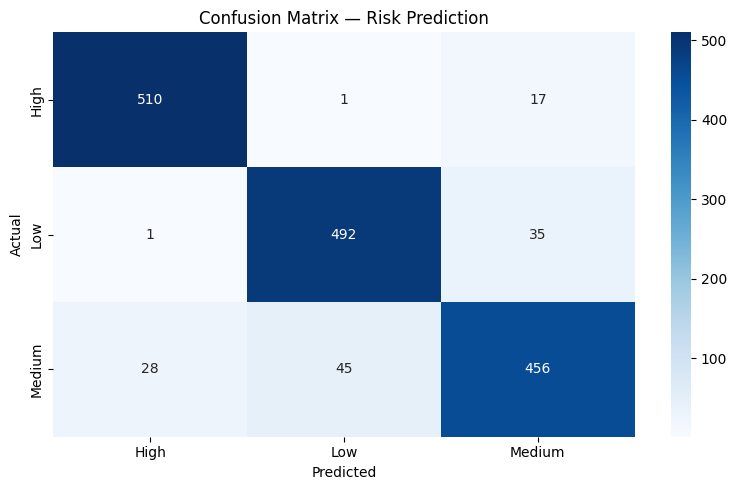

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(
    y_test,
    y_pred,
    target_names=risk_encoder.classes_
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=risk_encoder.classes_,
    yticklabels=risk_encoder.classes_,
    cmap='Blues'
)
plt.title('Confusion Matrix — Risk Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Computing SHAP values...


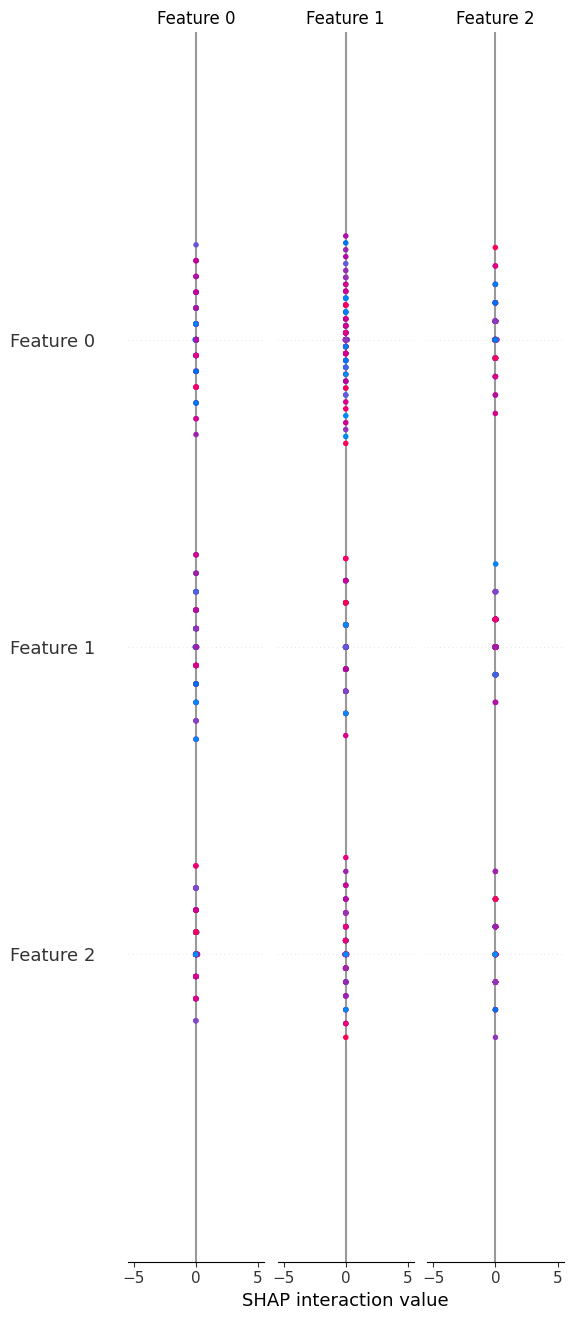

In [28]:
import shap

print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:100])

shap.summary_plot(
    shap_values,
    X_test[:100],
    class_names=risk_encoder.classes_,
    max_display=15
)

In [29]:
import joblib

joblib.dump(model, 'risk_model.pkl')
joblib.dump(risk_encoder, 'risk_encoder.pkl')
joblib.dump(ohe, 'ohe_encoder.pkl')
joblib.dump(encoder, 'sentence_encoder.pkl')

df.to_csv('mtsamples_final.csv', index=False)
print("All models saved ✅")

All models saved ✅
